<a href="https://colab.research.google.com/github/nguyenxuandinhit/TH_Deep_Learning/blob/main/Deep_Tuan4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================
# BÀI 1: CIFAR-10
# ============================================================

# 1. Nạp dữ liệu CIFAR-10
(X_train_cf, y_train_cf), (X_test_cf, y_test_cf) = keras.datasets.cifar10.load_data()

CLASS_NAMES_CIFAR = ['airplane','automobile','bird','cat','deer',
                     'dog','frog','horse','ship','truck']
NUM_CLASSES = 10

print('X_train shape:', X_train_cf.shape)  # (50000, 32, 32, 3)
print('X_test shape :', X_test_cf.shape)   # (10000, 32, 32, 3)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
X_train shape: (50000, 32, 32, 3)
X_test shape : (10000, 32, 32, 3)


/tmp/ipykernel_391/462781401.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(CLASS_NAMES_CIFAR[int(y_train_cf[i])], fontsize=11)


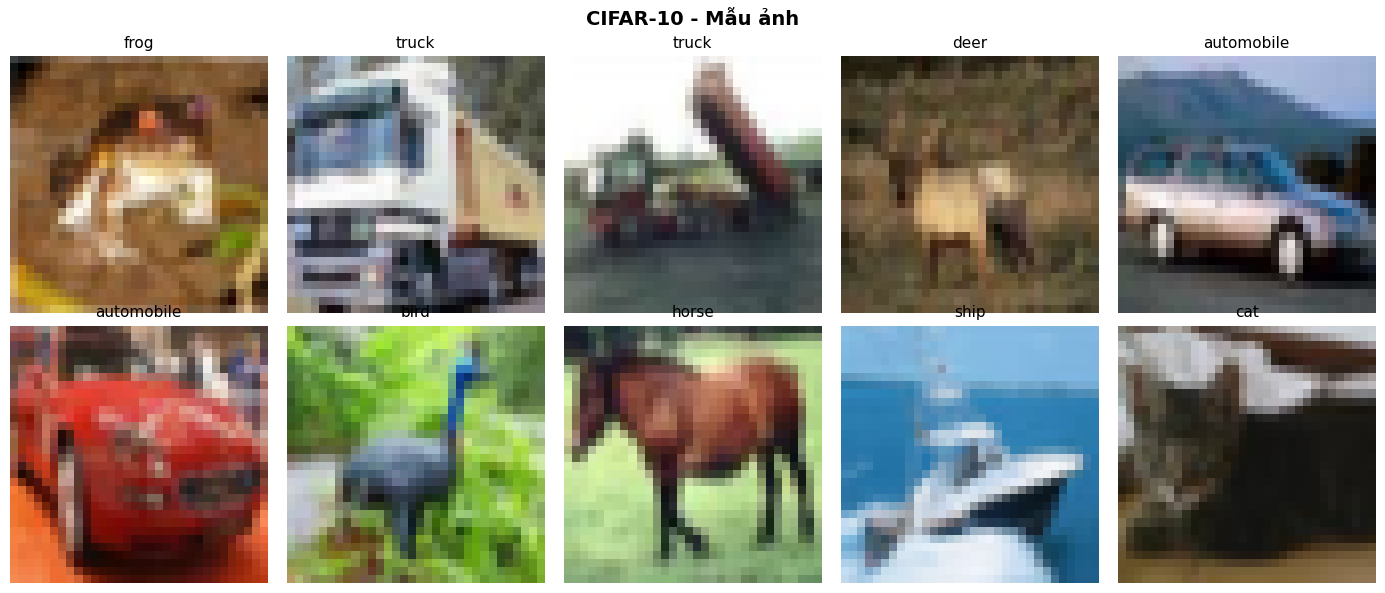

In [ ]:
# 2. Trực quan hóa một số ảnh mẫu
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_train_cf[i])
    ax.set_title(CLASS_NAMES_CIFAR[int(y_train_cf[i])], fontsize=11)
    ax.axis('off')
plt.suptitle('CIFAR-10 - Mẫu ảnh', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# 3. Tiền xử lý dữ liệu
X_train_cf = X_train_cf.astype('float32') / 255.0
X_test_cf  = X_test_cf.astype('float32') / 255.0

y_train_cf_cat = keras.utils.to_categorical(y_train_cf, NUM_CLASSES)
y_test_cf_cat  = keras.utils.to_categorical(y_test_cf,  NUM_CLASSES)

In [ ]:
# 4. Xây dựng mô hình CNN cho CIFAR-10
def build_cifar_model():
    model = Sequential([
        Input(shape=(32, 32, 3)),

        # Block 1
        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        MaxPool2D(pool_size=(2,2)),
        Dropout(0.25),

        # Block 2
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        MaxPool2D(pool_size=(2,2)),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPool2D(pool_size=(2,2)),
        Dropout(0.25),

        # Fully connected
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

model_cf = build_cifar_model()
model_cf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,434 (2.55 MB)

 Trainable params: 666,986 (2.54 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# 5. Compile & Huấn luyện
model_cf.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_cf = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6)
]

history_cf = model_cf.fit(
    X_train_cf, y_train_cf_cat,
    batch_size=64,
    epochs=30,
    validation_split=0.1,
    callbacks=callbacks_cf,
    verbose=1
)

Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.3729 - loss: 1.7354 - val_accuracy: 0.4992 - val_loss: 1.4451 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5165 - loss: 1.3412 - val_accuracy: 0.5688 - val_loss: 1.3083 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5880 - loss: 1.1593 - val_accuracy: 0.6608 - val_loss: 0.9823 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6394 - loss: 1.0298 - val_accuracy: 0.6938 - val_loss: 0.8811 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6701 - loss: 0.9461 - val_accuracy: 0.7128 - val_loss: 0.8448 - learning_rate: 0.0010
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6984 - loss: 0.8727 - val_accuracy: 0.7496 - val_loss: 0.7393 - learning_rate: 0.0010
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7160 - loss: 0.8225 

[CIFAR-10] Test Loss    : 0.5216
[CIFAR-10] Test Accuracy: 83.87%


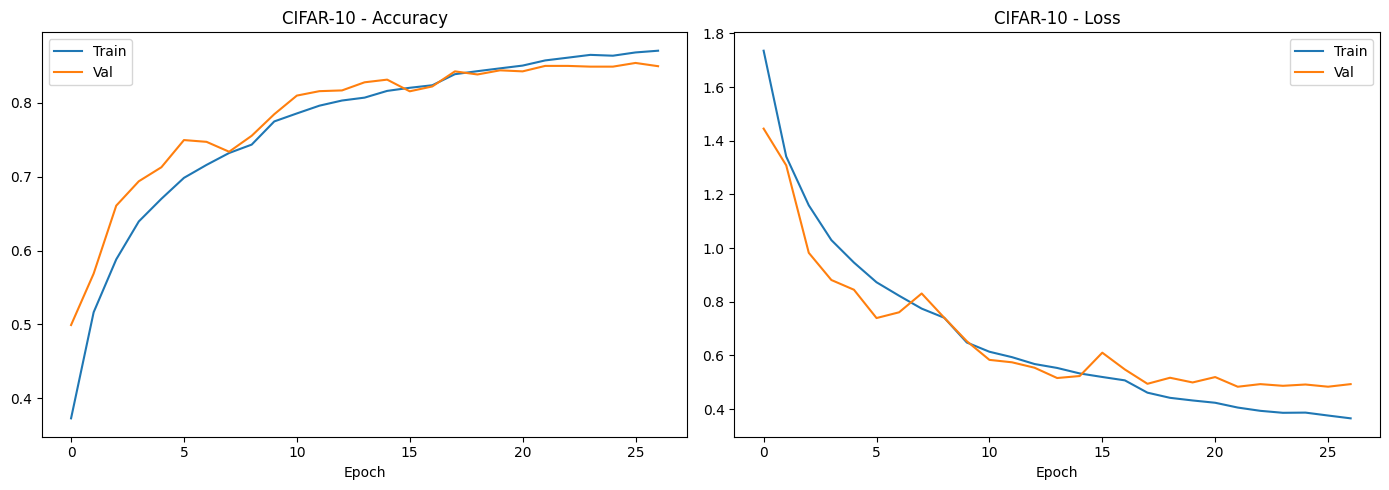

In [ ]:
# 6. Đánh giá & Vẽ biểu đồ
score_cf = model_cf.evaluate(X_test_cf, y_test_cf_cat, verbose=0)
print(f'[CIFAR-10] Test Loss    : {score_cf[0]:.4f}')
print(f'[CIFAR-10] Test Accuracy: {score_cf[1]*100:.2f}%')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_cf.history['accuracy'],     label='Train')
ax1.plot(history_cf.history['val_accuracy'], label='Val')
ax1.set_title('CIFAR-10 - Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history_cf.history['loss'],     label='Train')
ax2.plot(history_cf.history['val_loss'], label='Val')
ax2.set_title('CIFAR-10 - Loss'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout(); plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 846ms/step


/tmp/ipykernel_391/3558863466.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label  = CLASS_NAMES_CIFAR[int(y_test_cf[i])]


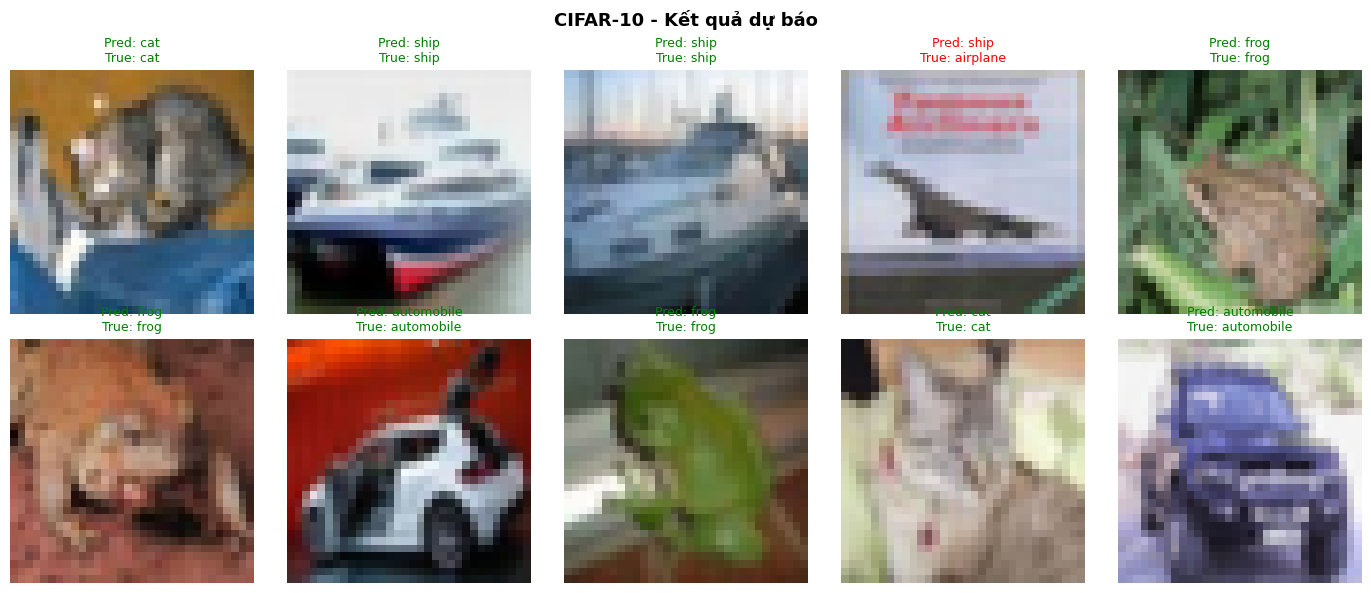

In [ ]:
# 7. Dự báo một số ảnh test
predictions_cf = model_cf.predict(X_test_cf[:10])

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_test_cf[i])
    pred_label  = CLASS_NAMES_CIFAR[np.argmax(predictions_cf[i])]
    true_label  = CLASS_NAMES_CIFAR[int(y_test_cf[i])]
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f'Pred: {pred_label}\nTrue: {true_label}', color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('CIFAR-10 - Kết quả dự báo', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [13]:
# ============================================================
# BÀI 2: CAT vs DOG
# Dùng tensorflow_datasets (không cần tải file thủ công)
# ============================================================

# Nếu giảng viên cung cấp dữ liệu theo thư mục:
# train/
#   cats/  *.jpg
#   dogs/  *.jpg
# test/
#   cats/  *.jpg
#   dogs/  *.jpg
#
# Thay TRAIN_DIR và TEST_DIR phía dưới bằng đường dẫn thực tế
# Ví dụ: TRAIN_DIR = '/content/drive/MyDrive/catdog/train'

USE_TFDS = True  # Đặt False nếu dùng dữ liệu giảng viên cung cấp

IMG_SIZE_CD = (128, 128)
BATCH_SIZE  = 32

if USE_TFDS:
    import tensorflow_datasets as tfds

    (ds_train_cd, ds_test_cd), ds_info = tfds.load(
        'cats_vs_dogs',
        split=['train[:80%]', 'train[80%:]'],
        as_supervised=True,
        with_info=True
    )

    def preprocess_cd(image, label):
        image = tf.image.resize(image, IMG_SIZE_CD)
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    ds_train_cd = ds_train_cd.map(preprocess_cd).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    ds_test_cd  = ds_test_cd.map(preprocess_cd).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    CLASS_NAMES_CD = ['Cat', 'Dog']
    print('Dataset Cats vs Dogs đã nạp xong!')

else:
    # === Dùng dữ liệu giảng viên cung cấp ===
    TRAIN_DIR = '/content/catdog/train'  # <-- Thay đường dẫn tại đây
    TEST_DIR  = '/content/catdog/test'   # <-- Thay đường dẫn tại đây

    from tensorflow.keras.preprocessing.image import ImageDataGenerator

    train_gen = ImageDataGenerator(rescale=1./255, rotation_range=20,
                                   width_shift_range=0.1, height_shift_range=0.1,
                                   horizontal_flip=True)
    test_gen  = ImageDataGenerator(rescale=1./255)

    ds_train_cd = train_gen.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE_CD,
                                                batch_size=BATCH_SIZE, class_mode='binary')
    ds_test_cd  = test_gen.flow_from_directory(TEST_DIR,   target_size=IMG_SIZE_CD,
                                                batch_size=BATCH_SIZE, class_mode='binary')
    CLASS_NAMES_CD = list(ds_train_cd.class_indices.keys())
    print('Classes:', CLASS_NAMES_CD)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.XG3T27_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Dataset Cats vs Dogs đã nạp xong!


In [ ]:
# Xây dựng mô hình CNN cho Cat vs Dog
def build_catdog_model():
    model = Sequential([
        Input(shape=(*IMG_SIZE_CD, 3)),

        Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.25),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.25),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.25),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')  # Binary: cat=0, dog=1
    ])
    return model

model_cd = build_catdog_model()
model_cd.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,483,265 (32.36 MB)

 Trainable params: 8,482,817 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# Compile & Huấn luyện Cat vs Dog
model_cd.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks_cd = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=3)
]

history_cd = model_cd.fit(
    ds_train_cd,
    epochs=20,
    validation_data=ds_test_cd,
    callbacks=callbacks_cd,
    verbose=1
)

Epoch 1/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 45s 60ms/step - accuracy: 0.6375 - loss: 0.9577 - val_accuracy: 0.6692 - val_loss: 0.6300 - learning_rate: 0.0010
Epoch 2/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - accuracy: 0.7112 - loss: 0.5659 - val_accuracy: 0.7188 - val_loss: 0.5556 - learning_rate: 0.0010
Epoch 3/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.7443 - loss: 0.5182 - val_accuracy: 0.7242 - val_loss: 0.5349 - learning_rate: 0.0010
Epoch 4/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.7690 - loss: 0.4843 - val_accuracy: 0.7756 - val_loss: 0.4652 - learning_rate: 0.0010
Epoch 5/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.7961 - loss: 0.4335 - val_accuracy: 0.8209 - val_loss: 0.4099 - learning_rate: 0.0010
Epoch 6/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.8207 - loss: 0.3965 - val_accuracy: 0.7646 - val_loss: 0.5047 - learning_rate: 0.0010
Epoch 7/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 27s 45ms/step - accuracy: 0.8391 - l

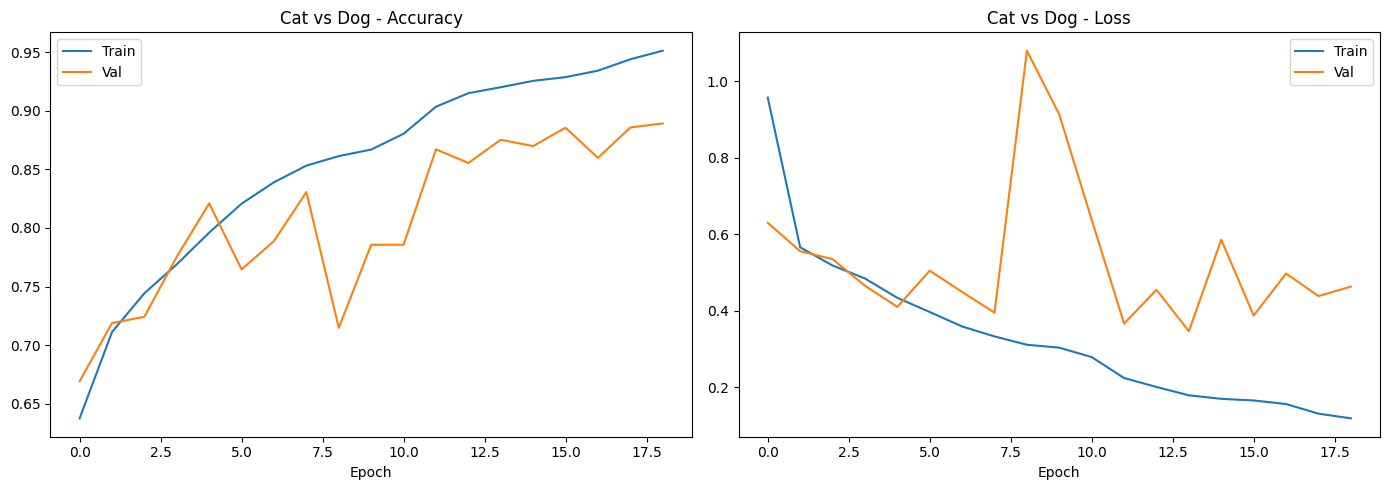

In [ ]:
# Đánh giá & vẽ biểu đồ Cat vs Dog
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_cd.history['accuracy'],     label='Train')
ax1.plot(history_cd.history['val_accuracy'], label='Val')
ax1.set_title('Cat vs Dog - Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history_cd.history['loss'],     label='Train')
ax2.plot(history_cd.history['val_loss'], label='Val')
ax2.set_title('Cat vs Dog - Loss'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout(); plt.show()

Saving images.jpg to images (1).jpg
User uploaded file "images (1).jpg"
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


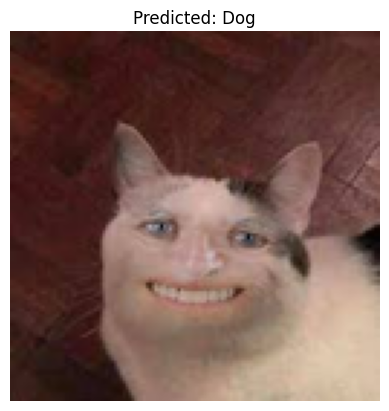

In [14]:
from PIL import Image
from google.colab import files
import io
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Dropout, BatchNormalization, Input

# Define IMG_SIZE_CD and CLASS_NAMES_CD locally for this cell's robustness
IMG_SIZE_CD = (128, 128) # Copied from cell R0YHp_Ho5Jnb
CLASS_NAMES_CD = ['Cat', 'Dog'] # Copied from cell R0YHp_Ho5Jnb

# Function to load and preprocess a single image
def load_and_preprocess_image(image_path, target_size=IMG_SIZE_CD):
    img = Image.open(image_path).convert('RGB')
    img = img.resize(target_size)
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = img_array.astype('float32') / 255.0 # Normalize
    return img_array

# Xây dựng mô hình CNN cho Cat vs Dog (Copied from cell HqTYjSdX5Jnb)
def build_catdog_model():
    model = Sequential([
        Input(shape=(*IMG_SIZE_CD, 3)),

        Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.25),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.25),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPool2D(2,2),
        Dropout(0.25),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')  # Binary: cat=0, dog=1
    ])
    return model

model_cd = build_catdog_model()
# Compile the model (copied from cell 0dSy54HX5Jnb to ensure it's ready for prediction)
model_cd.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Upload an image
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}"')
    img_path = io.BytesIO(uploaded[fn]) # Use BytesIO for uploaded file content

    # Preprocess the image
    processed_image = load_and_preprocess_image(img_path)

    # Make a prediction
    prediction = model_cd.predict(processed_image)
    # For binary classification, prediction is a single value, 0 or 1
    predicted_class_idx = (prediction[0] > 0.5).astype("int32")
    predicted_label = CLASS_NAMES_CD[predicted_class_idx[0]]

    # Display the image and prediction
    plt.imshow(processed_image[0])
    plt.title(f'Predicted: {predicted_label}')
    plt.axis('off')
    plt.show()

X_train shape: (60000, 28, 28, 1)


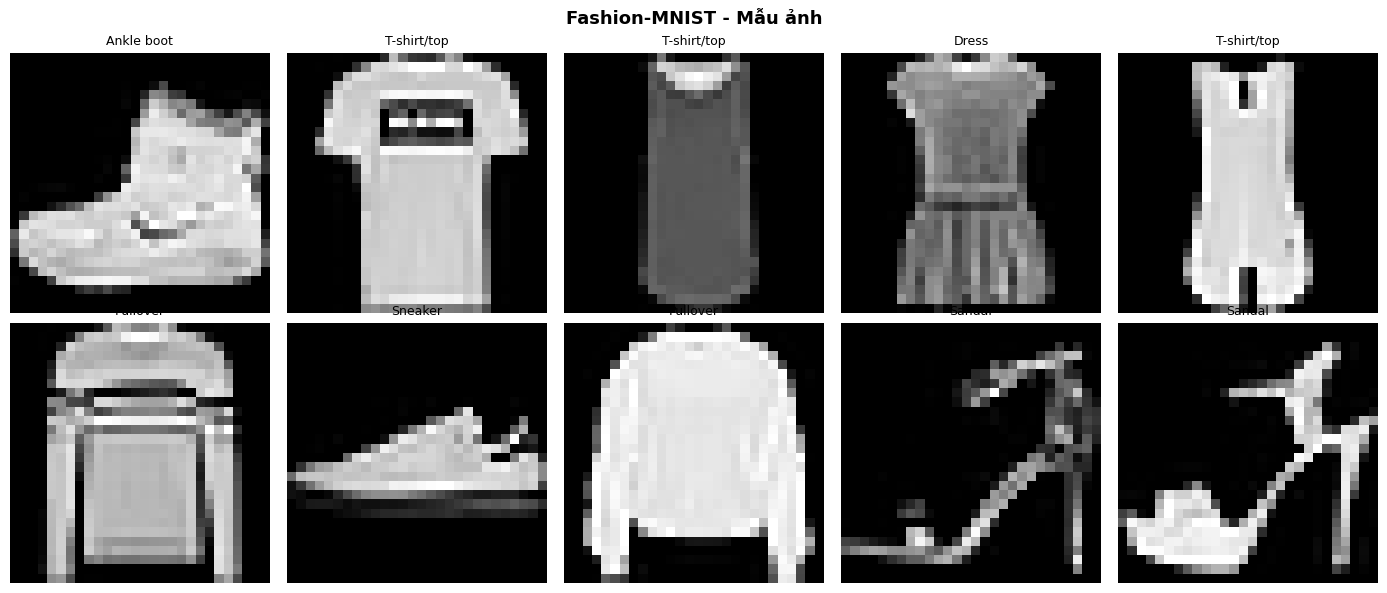

In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt

 # ============================================================
# BÀI 3: FASHION-MNIST
# ============================================================

CLASS_NAMES_FM = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
                  'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# Nạp dữ liệu (có sẵn trong Keras)
(X_train_fm, y_train_fm), (X_test_fm, y_test_fm) = tf.keras.datasets.fashion_mnist.load_data()

# Tiền xử lý
X_train_fm = X_train_fm.astype('float32') / 255.0
X_test_fm  = X_test_fm.astype('float32') / 255.0
X_train_fm = X_train_fm.reshape(-1, 28, 28, 1)
X_test_fm  = X_test_fm.reshape(-1, 28, 28, 1)

y_train_fm_cat = tf.keras.utils.to_categorical(y_train_fm, 10)
y_test_fm_cat  = tf.keras.utils.to_categorical(y_test_fm,  10)

print('X_train shape:', X_train_fm.shape)

# Trực quan hóa
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_train_fm[i].reshape(28,28), cmap='gray')
    ax.set_title(CLASS_NAMES_FM[y_train_fm[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('Fashion-MNIST - Mẫu ảnh', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Dropout, BatchNormalization, Input

# Xây dựng & huấn luyện CNN cho Fashion-MNIST
model_fm = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model_fm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fm.summary()

history_fm = model_fm.fit(
    X_train_fm, y_train_fm_cat,
    batch_size=128,
    epochs=20,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,026 (1.61 MB)

 Trainable params: 421,834 (1.61 MB)

 Non-trainable params: 192 (768.00 B)

NameError: name 'EarlyStopping' is not defined

In [ ]:
# Đánh giá Fashion-MNIST
score_fm = model_fm.evaluate(X_test_fm, y_test_fm_cat, verbose=0)
print(f'[Fashion-MNIST] Test Loss    : {score_fm[0]:.4f}')
print(f'[Fashion-MNIST] Test Accuracy: {score_fm[1]*100:.2f}%')

# Dự báo và hiển thị
preds_fm = model_fm.predict(X_test_fm[:10])
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_test_fm[i].reshape(28,28), cmap='gray')
    pred  = CLASS_NAMES_FM[np.argmax(preds_fm[i])]
    true  = CLASS_NAMES_FM[y_test_fm[i]]
    color = 'green' if pred == true else 'red'
    ax.set_title(f'P:{pred}\nT:{true}', color=color, fontsize=8)
    ax.axis('off')
plt.suptitle('Fashion-MNIST - Kết quả dự báo', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Vẽ accuracy/loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_fm.history['accuracy'],     label='Train')
ax1.plot(history_fm.history['val_accuracy'], label='Val')
ax1.set_title('Fashion-MNIST - Accuracy'); ax1.legend()
ax2.plot(history_fm.history['loss'],     label='Train')
ax2.plot(history_fm.history['val_loss'], label='Val')
ax2.set_title('Fashion-MNIST - Loss'); ax2.legend()
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# BÀI 4: NHẬN DẠNG GIỚI TÍNH (Nam / Nữ)
# ============================================================

# ===== OPTION A: Dùng dữ liệu giảng viên cung cấp =====
# Cấu trúc thư mục cần có:
# /content/gender/train/male/   *.jpg
# /content/gender/train/female/ *.jpg
# /content/gender/test/male/    *.jpg
# /content/gender/test/female/  *.jpg

USE_TEACHER_DATA = False  # Đặt True nếu có dữ liệu giảng viên

IMG_SIZE_GEN = (64, 64)
BATCH_SIZE_GEN = 32

if USE_TEACHER_DATA:
    from tensorflow.keras.preprocessing.image import ImageDataGenerator

    TRAIN_DIR_GEN = '/content/gender/train'  # <-- Sửa đường dẫn
    TEST_DIR_GEN  = '/content/gender/test'   # <-- Sửa đường dẫn

    train_gen_g = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        horizontal_flip=True,
        zoom_range=0.1
    )
    test_gen_g = ImageDataGenerator(rescale=1./255)

    ds_train_gen = train_gen_g.flow_from_directory(
        TRAIN_DIR_GEN, target_size=IMG_SIZE_GEN,
        batch_size=BATCH_SIZE_GEN, class_mode='binary'
    )
    ds_test_gen = test_gen_g.flow_from_directory(
        TEST_DIR_GEN, target_size=IMG_SIZE_GEN,
        batch_size=BATCH_SIZE_GEN, class_mode='binary'
    )
    print('Classes:', ds_train_gen.class_indices)

else:
    # ===== OPTION B: Dùng CelebA (tensorflow_datasets) =====
    # Thuộc tính 'Male' làm nhãn giới tính
    import tensorflow_datasets as tfds

    ds_celeba, info_celeba = tfds.load(
        'celeb_a',
        split=['train', 'test'],
        with_info=True,
        as_supervised=False
    )

    def preprocess_celeba(example):
        img   = tf.image.resize(example['image'], IMG_SIZE_GEN)
        img   = tf.cast(img, tf.float32) / 255.0
        label = tf.cast(example['attributes']['Male'], tf.int32)
        return img, label

    ds_train_gen = ds_celeba[0].map(preprocess_celeba).shuffle(2000).batch(BATCH_SIZE_GEN).prefetch(tf.data.AUTOTUNE)
    ds_test_gen  = ds_celeba[1].map(preprocess_celeba).batch(BATCH_SIZE_GEN).prefetch(tf.data.AUTOTUNE)
    print('CelebA loaded! Label: 0=Female, 1=Male')

In [ ]:
# Xây dựng CNN cho bài toán giới tính
model_gen = Sequential([
    Input(shape=(*IMG_SIZE_GEN, 3)),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # 0=Female, 1=Male
])

model_gen.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model_gen.summary()

In [ ]:
# Huấn luyện mô hình giới tính
history_gen = model_gen.fit(
    ds_train_gen,
    epochs=15,
    validation_data=ds_test_gen,
    callbacks=[
        EarlyStopping(patience=4, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.5, patience=2)
    ],
    verbose=1
)

# Vẽ biểu đồ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_gen.history['accuracy'],     label='Train')
ax1.plot(history_gen.history['val_accuracy'], label='Val')
ax1.set_title('Gender - Accuracy'); ax1.legend()
ax2.plot(history_gen.history['loss'],     label='Train')
ax2.plot(history_gen.history['val_loss'], label='Val')
ax2.set_title('Gender - Loss'); ax2.legend()
plt.tight_layout(); plt.show()